# UC-Bench v0.5: locked anti-TNF predictor diligence

> **Pre-calibration notebook.** No v0.5 model or Astra calls have been made. Controlled reference behavior is real environment output; model heatmaps below are explicitly illustrative mockups.

The agent is a cross-functional technical diligence lead. It does not need to build a better predictor. It must decide which claims are admissible, whether the asset should advance, and which single follow-up investment has the highest decision value. Correctly stopping is success when the evidence is inadequate.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent
controls = json.loads((ROOT / 'artifacts/diagnostics/hard_suite_v05_controls.json').read_text())
report = json.loads((ROOT / 'artifacts/diagnostics/hard_suite_v05_precalibration.json').read_text())
config = json.loads((ROOT / 'configs/hard_suite_v05.json').read_text())
print('Local gates:', 'PASS' if controls['all_local_gates_passed'] else 'FAIL')
print('v0.5 model calls:', report['model_calls'], '| Astra requests:', report['astra_requests'])

Local gates: PASS
v0.5 model calls: 0 | Astra requests: 0


## What exists, and what the agent does

The start state contains ordinary diligence artifacts: an intended-use contract, cohort registry, data-room manifest, patient/visit prediction tables, endpoint reviewers, platform and preprocessing history, a locked predictor, reproduction fixtures, a metric contract, and a costed resource catalog. External outcomes, counterfactual resource packets, scenario truth, and graders remain host-only.

The agent works through all ten milestones in one workspace. Earlier findings restrict related claims without mechanically zeroing unrelated later work.

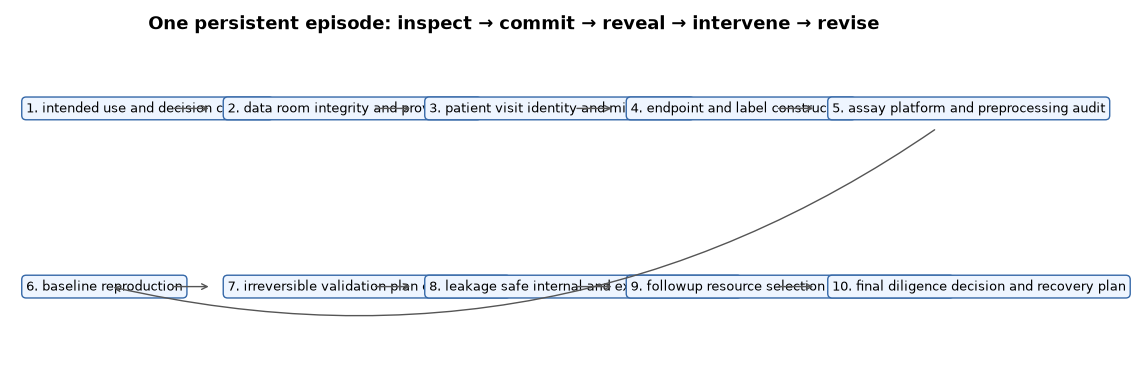

In [2]:
milestones = [row['name'].replace('_', ' ') for row in config['milestones']]
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 5)
ax.set_ylim(-0.8, 2)
ax.axis('off')
for i, label in enumerate(milestones):
    row, col = divmod(i, 5)
    x = col + 0.08
    y = 1.25 - row * 1.35
    ax.text(x, y, f'{i+1}. {label}', ha='left', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', fc='#eef5ff', ec='#3568a8'))
    if col < 4:
        ax.annotate('', xy=(x + 0.92, y), xytext=(x + 0.72, y),
                    arrowprops=dict(arrowstyle='->', color='#555'))
ax.annotate('', xy=(0.5, -0.1), xytext=(4.6, 1.1),
            arrowprops=dict(arrowstyle='->', color='#555', connectionstyle='arc3,rad=-0.22'))
ax.text(2.5, 1.85, 'One persistent episode: inspect → commit → reveal → intervene → revise',
        ha='center', fontsize=13, weight='bold')
plt.show()

## The irreversible evidence boundary

```text
PUBLIC DATA ROOM
      │
      ├── commitment.json ── commit_validation_plan() ── hash predictor + plan
      │                                                   │
      │                                      sealed outcomes revealed
      │                                                   │
      ├── validation_assessment.json ── request_followup() ── lock one resource
      │                                                   │
      │                                      one evidence packet revealed
      │                                                   │
      └── final_submission.json ── submit_diligence() ── verify both hashes
```

The resource may resolve the blocker, reduce uncertainty, expose another blocker, fail, or create misleading reassurance. The grader tests whether the agent updates only the claims that the new evidence actually bears on.

In [3]:
states = pd.DataFrame(report['controlled_reference_states'])
states['state'] = states['scenario_class'].str.replace('_', ' ')
states['decision'] = states['decision_transition'].apply(lambda x: ' → '.join(x))
states[['state', 'active_initial_blockers', 'optimal_resource', 'intervention_effect', 'decision']]

,state,active_initial_blockers,optimal_resource,intervention_effect,decision
0,clean enough progression,[],none,no_resource_needed,conditional_advance → conditional_advance
1,patient identity dependence failure,"[identity, evidence]",R1,resolves_blocker,pause → conditional_advance
2,endpoint label ambiguity,"[endpoint, transport, evidence]",R2,exposes_second_blocker,pause → insufficient_evidence
3,batch or preprocessing leakage,"[preprocessing, transport, evidence]",R3,exposes_second_blocker,pause → stop
4,endpoint drug platform transfer failure,"[endpoint, transport, evidence]",R4,resolves_blocker,pause → conditional_advance
5,underpowered or irreducible external evidence,[evidence],R5,reduces_uncertainty_without_resolving,insufficient_evidence → insufficient_evidence


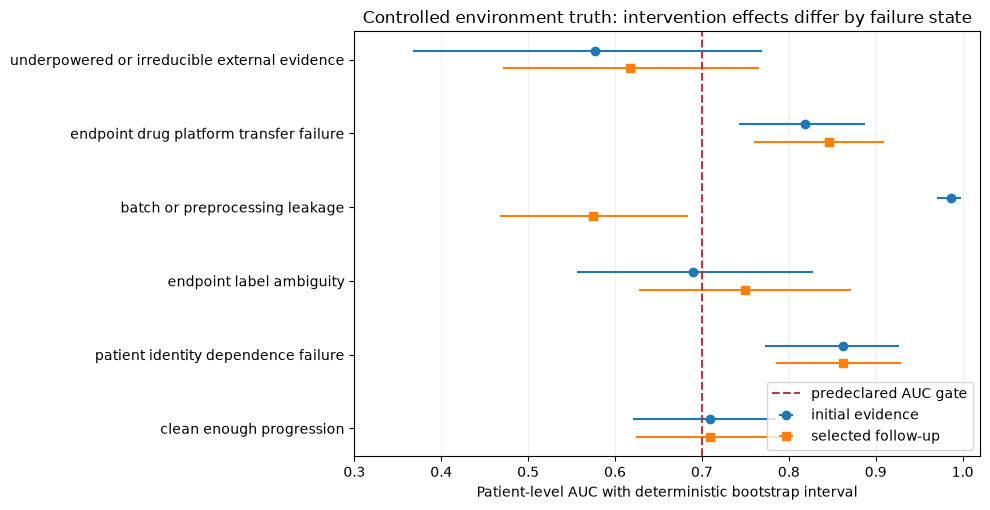

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.2))
y = np.arange(len(states))
initial = states['initial_auc'].to_numpy()
followup = states['followup_auc'].to_numpy()
initial_lo = np.array([x[0] for x in states['initial_auc_interval']])
initial_hi = np.array([x[1] for x in states['initial_auc_interval']])
follow_lo = np.array([x[0] for x in states['followup_auc_interval']])
follow_hi = np.array([x[1] for x in states['followup_auc_interval']])
ax.errorbar(initial, y + 0.12, xerr=[initial-initial_lo, initial_hi-initial], fmt='o', label='initial evidence')
ax.errorbar(followup, y - 0.12, xerr=[followup-follow_lo, follow_hi-followup], fmt='s', label='selected follow-up')
ax.axvline(0.70, color='#b23a48', linestyle='--', label='predeclared AUC gate')
ax.set_yticks(y, states['state'])
ax.set_xlim(0.3, 1.02)
ax.set_xlabel('Patient-level AUC with deterministic bootstrap interval')
ax.set_title('Controlled environment truth: intervention effects differ by failure state')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=.2)
plt.tight_layout()
plt.show()

The plot is not a predictor leaderboard. It shows why the environment can distinguish graceful failure: a very high apparent AUC may remain inadmissible, a process repair can collapse performance, and more data can narrow uncertainty without making advancement valid.

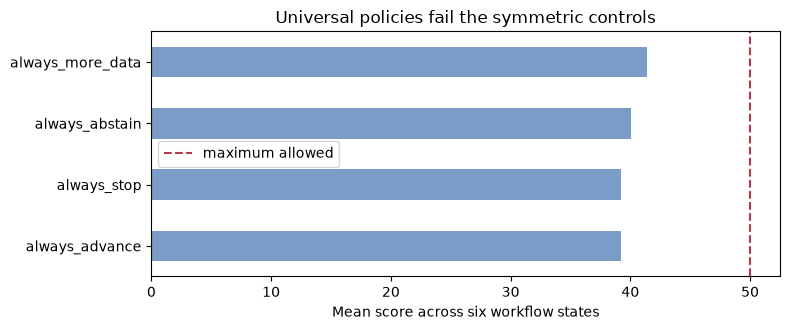

In [5]:
policies = pd.Series(controls['policy_mean_scores']).sort_values()
ax = policies.plot.barh(figsize=(8, 3.4), color='#7a9cc6')
ax.axvline(50, color='#b23a48', linestyle='--', label='maximum allowed')
ax.set_xlabel('Mean score across six workflow states')
ax.set_title('Universal policies fail the symmetric controls')
ax.legend()
plt.tight_layout()
plt.show()

## Mockup of the eventual model × milestone product

> The values in the next cell are **illustrative only**. They are not measurements and are deliberately labeled with non-model names. The actual report remains empty until paid development calibration passes its ceiling/floor gate.

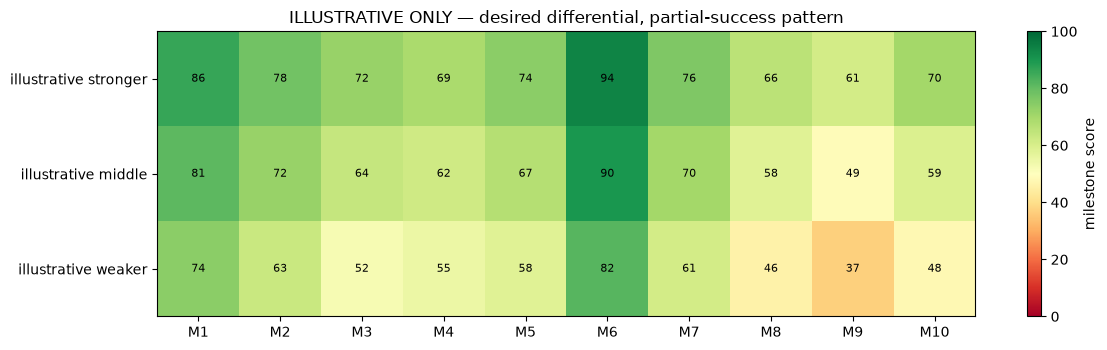

In [6]:
mock_models = ['illustrative stronger', 'illustrative middle', 'illustrative weaker']
mock = np.array([[86, 78, 72, 69, 74, 94, 76, 66, 61, 70],
                 [81, 72, 64, 62, 67, 90, 70, 58, 49, 59],
                 [74, 63, 52, 55, 58, 82, 61, 46, 37, 48]])
fig, ax = plt.subplots(figsize=(12, 3.6))
image = ax.imshow(mock, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(10), [f'M{i}' for i in range(1, 11)])
ax.set_yticks(range(3), mock_models)
for i in range(mock.shape[0]):
    for j in range(mock.shape[1]):
        ax.text(j, i, mock[i, j], ha='center', va='center', fontsize=8)
ax.set_title('ILLUSTRATIVE ONLY — desired differential, partial-success pattern')
fig.colorbar(image, ax=ax, label='milestone score')
plt.tight_layout()
plt.show()

## How failure claims will be reported

| Layer | Allowed statement |
|---|---|
| Observed behavior | Exact file, action, metric, unsupported claim, or missed update |
| Capability diagnosis | Pattern supported across milestones, states, and seeds |
| Hypothesized training cause | Explicitly speculative; never inferred from a low score alone |
| Demonstrated remedy | Only a paired intervention whose reveal measurably changes behavior |

The eventual public output leads with model × milestone, model × capability, model × failure mode, paired rescue effects, breaking-point curves, and replay traces. Aggregate rank is secondary and requires repeated seeds.

In [7]:
checks = pd.Series(controls['checks'], name='passed').rename_axis('local gate').to_frame()
checks

,passed
local gate,
alternative_method_minimum_90,True
astra_unexposed,True
committed_mutation_rejected,True
configuration_valid,True
decisions_are_symmetric,True
intervention_effects_are_heterogeneous,True
pre_reveal_has_no_outcomes_or_private_answers,True
reference_beats_mediocre_each_milestone,True
reference_beats_mediocre_each_scenario,True


## Operator handoff

Local verification is free:

```bash
PYTHONPATH=src ./.venv/bin/python scripts/build_v05_controls.py
PYTHONPATH=src ./.venv/bin/python -m pytest tests/test_hard_suite_v05.py
PYTHONPATH=src ./.venv/bin/python scripts/run_v05_calibration.py
```

The last command is planning-only unless `--execute` and the exact frozen cost cap are explicitly supplied. Astra is not present in the development matrix and is rejected by the paid runner.